# Model Training v3 (XGBoost)


## Objective

This notebook trains a third-generation model using the enhanced feature set created in `03_feature_engineering_v3.ipynb` and the XGBoost algorithm.

The goals are to:

- leverage richer spatial, directional, interaction, and temporal features,
- evaluate whether XGBoost outperforms earlier Random Forest baselines,
- reduce overall prediction error for `ball_land_x` and `ball_land_y`,
- and produce reproducible training artifacts for downstream evaluation and deployment.

## Why XGBoost

XGBoost is a strong gradient boosting model for tabular data and is often more effective than Random Forest when the feature set contains meaningful nonlinear interactions and engineered signals.

This makes it a strong candidate for evaluating the value of the v3 feature set.

In [12]:
import sys
from pathlib import Path
import json
from datetime import datetime
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from xgboost import XGBRegressor

sys.path.append(str(Path("..").resolve()))

from src.config import PROCESSED_DIR, MODELS_DIR, REPORTS_DIR

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

##  Load v3 Dataset

We begin by loading the enriched v3 dataser, which contains the baseline, spatial, and temporal features engineered in the previous notebook.

In [2]:
# Load processed dataset
input_path = PROCESSED_DIR / "baseline_train_v3.parquet"
df = pd.read_parquet(input_path)

print("Loaded v3 dataset shape:", df.shape)
display(df.head())



Loaded v3 dataset shape: (152305, 48)


,game_id,play_id,nfl_id,player_name,frame_id,x,y,s,a,dir,o,absolute_yardline_number,player_weight,player_height_inches,player_age,is_moving_right,player_position,player_side,player_role,ball_land_x,ball_land_y,num_frames_output,dist_to_ball,speed_x,speed_y,acc_vector,x_centered,y_centered,momentum,speed_times_dir,x_times_speed,speed_bin_code,dx_to_ball,dy_to_ball,acc_x,acc_y,dir_minus_o,momentum_x,momentum_y,dist_from_field_center,x_prev,y_prev,s_prev,a_prev,delta_x,delta_y,delta_s,delta_a
0,2023090700,101,44930,Josh Reynolds,1,41.03,12.17,0.00,0.00,156.35,80.97,42,196,75,28,1,WR,Offense,Targeted Receiver,63.259998,-0.22,21,25.449655,-0.000000,0.000000,0.00,-18.97,-14.48,0.00,0.0000,0.0000,0,22.229998,-12.39,-0.000000,0.000000,75.38,-0.000000,0.000000,23.864855,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,2023090700,101,44930,Josh Reynolds,2,41.03,12.17,0.00,0.00,119.09,82.26,42,196,75,28,1,WR,Offense,Targeted Receiver,63.259998,-0.22,21,25.449655,-0.000000,0.000000,0.00,-18.97,-14.48,0.00,0.0000,0.0000,0,22.229998,-12.39,-0.000000,0.000000,36.83,-0.000000,0.000000,23.864855,41.03,12.17,0.00,0.00,0.00,28.86,41.03,41.03
2,2023090700,101,44930,Josh Reynolds,3,41.05,12.18,0.02,0.47,65.03,83.33,42,196,75,28,1,WR,Offense,Targeted Receiver,63.259998,-0.22,21,25.437060,0.008443,0.018131,0.47,-18.95,-14.47,3.92,1.3006,0.8210,0,22.209998,-12.40,0.198408,0.426069,-18.30,1.654803,3.553593,23.842890,41.03,12.17,0.00,0.00,0.02,28.88,41.05,41.05
3,2023090700,101,44930,Josh Reynolds,4,41.07,12.20,0.18,1.54,56.06,84.29,42,196,75,28,1,WR,Offense,Targeted Receiver,63.259998,-0.22,21,25.429361,0.100498,0.149332,1.54,-18.93,-14.45,35.28,10.0908,7.3926,0,22.189998,-12.42,0.859820,1.277619,-28.23,19.697686,29.269089,23.814857,41.05,12.18,0.02,0.47,0.02,28.89,41.05,40.60
4,2023090700,101,44930,Josh Reynolds,5,41.11,12.22,0.57,3.09,59.41,88.21,42,196,75,28,1,WR,Offense,Targeted Receiver,63.259998,-0.22,21,25.404252,0.290068,0.490674,3.09,-18.89,-14.43,111.72,33.8637,23.4327,0,22.149998,-12.44,1.572474,2.659967,-28.80,56.853323,96.172023,23.770928,41.07,12.20,0.18,1.54,0.04,28.91,40.93,39.57


## Define Features and Targets

We define the v3 modeling feature set by combining :

- baseline movement variables,
- player/context features,
- spatial relationship features,
- directional decomposition features,
- interaction features,
- and simple temporal features.

We keep metadata columns such as "player_name" out of the model inputs.



In [3]:
target_cols = ["ball_land_x", "ball_land_y"]

feature_cols = [
    # Baseline features
    "x",
    "y",
    "s",
    "a",
    "dir",
    "o",
    "absolute_yardline_number",
    "player_weight",
    "player_height_inches",
    "player_age",
    "is_moving_right",
    "player_position",
    "player_side",
    "player_role",

    # v2 features
    "dx_to_ball",
    "dy_to_ball",
    "dist_to_ball",
    "speed_x",
    "speed_y",
    "momentum",
    "momentum_x",
    "momentum_y",
    "x_centered",
    "y_centered",
    "dist_from_field_center",
    "speed_bin_code",

    # v3 features
    "acc_x",
    "acc_y",
    "dir_minus_o",
    "x_prev",
    "y_prev",
    "s_prev",
    "a_prev",
    "delta_x",
    "delta_y",
    "delta_s",
    "delta_a",
]

categorical_cols = [
    "player_position",
    "player_side",
    "player_role",
]

X = df[feature_cols].copy()
y_x = df["ball_land_x"].copy()
y_y = df["ball_land_y"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape (ball_land_x):", y_x.shape)
print("Target shape (ball_land_y):", y_y.shape)
print("\nCategorical columns:", categorical_cols)

Feature matrix shape: (152305, 37)
Target shape (ball_land_x): (152305,)
Target shape (ball_land_y): (152305,)

Categorical columns: ['player_position', 'player_side', 'player_role']


## Missing Value Check

Before training, we verify missing values in the final v3 feature matrix. This is especially important after adding temporal features.

In [4]:
missing_percent = X.isnull().mean().sort_values(ascending=False)
display(missing_percent[missing_percent > 0])

print("Missing target values:")
print("ball_land_x:", y_x.isnull().sum())
print("ball_land_y:", y_y.isnull().sum())

Series([], dtype: float64)

Missing target values:
ball_land_x: 0
ball_land_y: 0


##  Train / Validation Split

To reduce leakage and keep comparisons fair across iterations, we use the same grouped split strategy by "game_id".

In [5]:
unique_games = df["game_id"].dropna().unique()
unique_games = np.sort(unique_games)

rng = np.random.default_rng(42)
shuffled_games = rng.permutation(unique_games)

split_idx = int(0.8 * len(shuffled_games))
train_games = set(shuffled_games[:split_idx])
valid_games = set(shuffled_games[split_idx:])

train_mask = df["game_id"].isin(train_games)
valid_mask = df["game_id"].isin(valid_games)

print("Number of unique games:", len(unique_games))
print("Training games:", len(train_games))
print("Validation games:", len(valid_games))

Number of unique games: 32
Training games: 25
Validation games: 7


## Feature Encoding

Because XGBoost requires numerical inputs, categorical variables are one-hot encoded before training.

In [6]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, dummy_na=True)

X_train = X_encoded.loc[train_mask].copy()
X_valid = X_encoded.loc[valid_mask].copy()

y_train_x = y_x.loc[train_mask].copy()
y_valid_x = y_x.loc[valid_mask].copy()

y_train_y = y_y.loc[train_mask].copy()
y_valid_y = y_y.loc[valid_mask].copy()

print("Encoded training shape:", X_train.shape)
print("Encoded validation shape:", X_valid.shape)
print("Training rows:", X_train.shape[0])
print("Validation rows:", X_valid.shape[0])

Encoded training shape: (121480, 55)
Encoded validation shape: (30825, 55)
Training rows: 121480
Validation rows: 30825


In [7]:
trained_feature_columns = list(X_train.columns)
print("Number of trained features:", len(trained_feature_columns))

Number of trained features: 55


## Native Baseline Benchmark

Before trainig the v3 models, we compute a native benchmark using the mean training target value.

In [14]:
baseline_pred_x = np.full_like(y_valid_x, y_train_x.mean(), dtype=float)
baseline_pred_y = np.full_like(y_valid_y, y_train_y.mean(), dtype=float)

baseline_metrics_x = {
    "MAE": mean_absolute_error(y_valid_x, baseline_pred_x),
    "RMSE": root_mean_squared_error(y_valid_x, baseline_pred_x),
    "R2": r2_score(y_valid_x, baseline_pred_x),
}

baseline_metrics_y = {
    "MAE": mean_absolute_error(y_valid_y, baseline_pred_y),
    "RMSE": root_mean_squared_error(y_valid_y, baseline_pred_y),
    "R2": r2_score(y_valid_y, baseline_pred_y),
}

baseline_metrics_df = pd.DataFrame({
    "ball_land_x_baseline": baseline_metrics_x,
    "ball_land_y_baseline": baseline_metrics_y,
})

display(baseline_metrics_df)

,ball_land_x_baseline,ball_land_y_baseline
MAE,20.976016,13.747809
RMSE,25.432954,15.854705
R2,-0.000529,-0.000052


##  Model Selection

We use 'XGBRegressor' as the v3 modeling algoritm.

XGBoost is expected to better exploit the richer feature set by learning nonlinear relantionship and complex interactions more effectively than the previous Random Forest baseline.

In [16]:
model_x = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

model_y =  XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

## Train v3 Models

We fit two separate CGBoost regression models:
- one for "ball_land_x"
- one for "ball_land_y"

In [17]:
model_x.fit(X_train, y_train_x)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=400, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [18]:
model_y.fit(X_train, y_train_y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=400, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

## Generate Validation Predictions

We generate validation predictions while preserving the original validation index for downstream alignmentin evaluation.

In [19]:
pred_valid_x = model_x.predict(X_valid)
pred_valid_y = model_y.predict(X_valid)

pred_df = pd.DataFrame({
    "ball_land_x_true": y_valid_x.values,
    "ball_land_x_pred": pred_valid_x,
    "ball_land_y_true": y_valid_y.values,
    "ball_land_y_pred": pred_valid_y,
}, index=y_valid_x.index)

pred_df["error_x"] = pred_df["ball_land_x_pred"] - pred_df["ball_land_x_true"]
pred_df["error_y"] = pred_df["ball_land_y_pred"] - pred_df["ball_land_y_true"]

display(pred_df.head())

,ball_land_x_true,ball_land_x_pred,ball_land_y_true,ball_land_y_pred,error_x,error_y
6371,55.57,55.454952,27.799999,28.032030,-0.115047,0.232031
6372,55.57,55.815922,27.799999,27.975599,0.245922,0.175600
6373,55.57,55.921875,27.799999,28.152121,0.351875,0.352121
6374,55.57,55.751289,27.799999,28.279974,0.181290,0.479975
6375,55.57,55.884941,27.799999,28.277689,0.314941,0.477690


##  Validation Performance

We compute standard regression metrics to assess the quality of the v3 XGBoost models.

In [20]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

metrics_x = regression_metrics(y_valid_x, pred_valid_x)
metrics_y = regression_metrics(y_valid_y, pred_valid_y)

metrics_df = pd.DataFrame({
    "ball_land_x_model": metrics_x,
    "ball_land_y_model": metrics_y,
})

display(metrics_df)

,ball_land_x_model,ball_land_y_model
MAE,0.403258,0.269173
RMSE,0.610052,0.479312
R2,0.999424,0.999086


##  Model vs Baseline Comparison

We compare the v3 XGBoost models against the naive baseline to verify that the model adds meaningful predictive value.

In [21]:
comparison_df = pd.concat([baseline_metrics_df, metrics_df], axis=1)
display(comparison_df)

,ball_land_x_baseline,ball_land_y_baseline,ball_land_x_model,ball_land_y_model
MAE,20.976016,13.747809,0.403258,0.269173
RMSE,25.432954,15.854705,0.610052,0.479312
R2,-0.000529,-0.000052,0.999424,0.999086


##  Prediction Diagnostics

To compare predicted and true values to visually inspect calibration and dispersion.

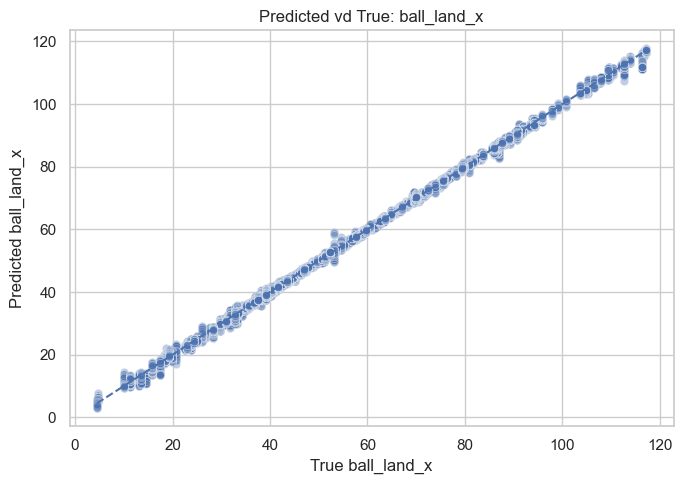

In [22]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_valid_x, y=pred_valid_x, alpha=0.35)
plt.plot([y_valid_x.min(),y_valid_x.max()],[y_valid_x.min(), y_valid_x.max()], linestyle="--")
plt.title("Predicted vd True: ball_land_x")
plt.xlabel("True ball_land_x")
plt.ylabel("Predicted ball_land_x")
plt.tight_layout()
plt.show()

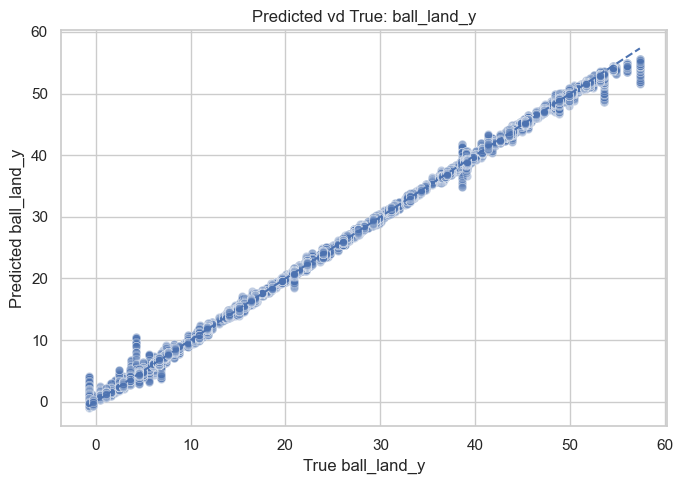

In [23]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_valid_y, y=pred_valid_y, alpha=0.35)
plt.plot([y_valid_y.min(),y_valid_y.max()],[y_valid_y.min(), y_valid_y.max()], linestyle="--")
plt.title("Predicted vd True: ball_land_y")
plt.xlabel("True ball_land_y")
plt.ylabel("Predicted ball_land_y")
plt.tight_layout()
plt.show()

##  Feature Importance

We inspect feature importance to identify which v3 features contribute most to the predictions.

In [24]:
importance_x = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_x.feature_importances_
}).sort_values("importance", ascending=False)

importance_y = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_y.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 10 features for ball_land_x:")
display(importance_x.head(10))

print("Top 10 features for ball_land_y:")
display(importance_y.head(10))

Top 10 features for ball_land_x:


,feature,importance
19,x_centered,0.411367
0,x,0.280921
26,x_prev,0.160872
11,dx_to_ball,0.056844
10,is_moving_right,0.033698
21,dist_from_field_center,0.027671
13,dist_to_ball,0.008710
27,y_prev,0.007695
6,absolute_yardline_number,0.004285
33,delta_a,0.003674


Top 10 features for ball_land_y:


,feature,importance
1,y,0.372766
12,dy_to_ball,0.322391
20,y_centered,0.198898
23,acc_x,0.021521
14,speed_x,0.019329
13,dist_to_ball,0.012970
49,player_side_Defense,0.007594
47,player_position_WR,0.006127
17,momentum_x,0.005930
50,player_side_Offense,0.004158


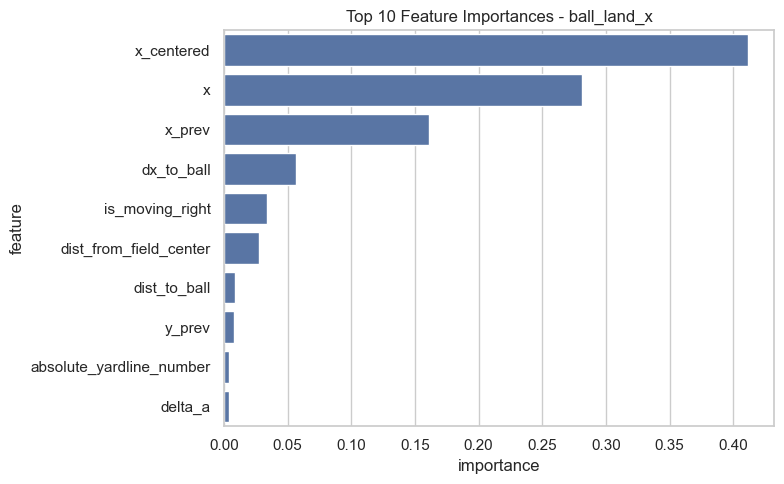

In [25]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_x.head(10), x="importance", y="feature")
plt.title("Top 10 Feature Importances - ball_land_x")
plt.tight_layout()
plt.show()

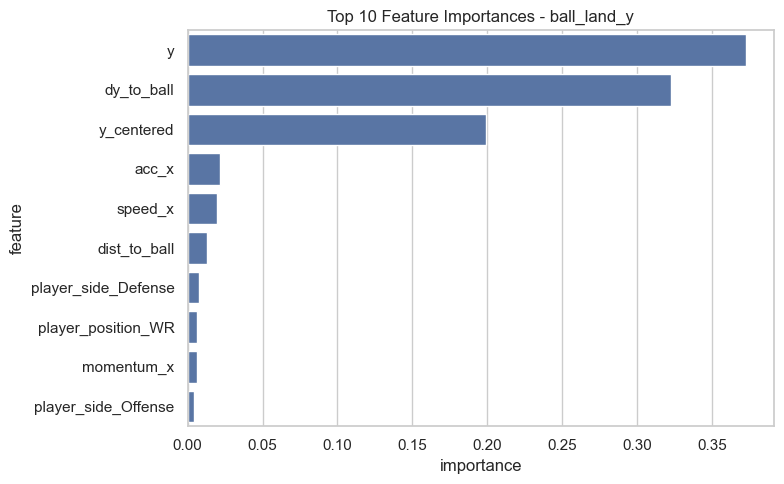

In [26]:
plt.figure(figsize=(8, 5))
sns.barplot(data=importance_y.head(10), x="importance", y="feature")
plt.title("Top 10 Feature Importances - ball_land_y")
plt.tight_layout()
plt.show()

## Save Artifacts

We save  the trained XGBoost models, feature definitions, predictions, and metadata for downstream evaluation and deployment.

In [27]:
# Create output directory for this training run
run_dir = MODELS_DIR / "baseline_v3_xgboost"
run_dir.mkdir(parents=True, exist_ok=True)

# Define artifact paths
model_x_path = run_dir / "model_ball_land_x.pkl"
model_y_path = run_dir / "model_ball_land_y.pkl"
features_path = run_dir / "feature_columns.json"
metadata_path = run_dir / "training_metadata.json"
predictions_path = run_dir / "validation_predictions.parquet"

# Save trained models
joblib.dump(model_x, model_x_path)
joblib.dump(model_y, model_y_path)

# Save the actual model input columns after one-hot encoding
trained_feature_columns = list(X_train.columns)

with open(features_path, "w") as f:
    json.dump(trained_feature_columns, f, indent=2)

# Save validation predictions with the preserved validation index
pred_df.to_parquet(predictions_path)

# Build metadata dictionary for traceability
metadata = {
    "run_name": "baseline_v3_xgboost",
    "created_at": datetime.now().isoformat(),
    "input_dataset": str(input_path),
    "n_rows_total": int(df.shape[0]),
    "n_rows_train": int(X_train.shape[0]),
    "n_rows_valid": int(X_valid.shape[0]),
    "target_columns": target_cols,
    "feature_columns_raw": feature_cols,
    "feature_columns_trained": trained_feature_columns,
    "categorical_columns": categorical_cols,
    "metrics_ball_land_x": metrics_x,
    "metrics_ball_land_y": metrics_y,
    "baseline_metrics_ball_land_x": baseline_metrics_x,
    "baseline_metrics_ball_land_y": baseline_metrics_y,
    "model_type": "RandomForestRegressor",
    "model_params": model_x.get_params(),
    "notes": "V3 XGBoost models trained on enhanced spatial, directional, interaction, and temporal features."
}

# Save metadata
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

# Confirm saved artifacts
print("Saved model_x to:", model_x_path)
print("Saved model_y to:", model_y_path)
print("Saved features to:", features_path)
print("Saved metadata to:", metadata_path)
print("Saved validation predictions to:", predictions_path)

Saved model_x to: C:\Users\jmontanez\Documents\nfl-big-data-bowl-2026\models\baseline_v3_xgboost\model_ball_land_x.pkl
Saved model_y to: C:\Users\jmontanez\Documents\nfl-big-data-bowl-2026\models\baseline_v3_xgboost\model_ball_land_y.pkl
Saved features to: C:\Users\jmontanez\Documents\nfl-big-data-bowl-2026\models\baseline_v3_xgboost\feature_columns.json
Saved metadata to: C:\Users\jmontanez\Documents\nfl-big-data-bowl-2026\models\baseline_v3_xgboost\training_metadata.json
Saved validation predictions to: C:\Users\jmontanez\Documents\nfl-big-data-bowl-2026\models\baseline_v3_xgboost\validation_predictions.parquet


## Final Summary and Key Takeaways (v3 - XGBoost)

### Overview

In this notebook, we trained a third-generation modeling pipeline using:

- an enriched v3 feature set,
- and the XGBoost algorithm as a more powerful alternative to Random Forest.

This iteration builds upon previous versions by incorporating:

- target-relative spatial features,
- directional movement decomposition,
- interaction-based features (momentum),
- and simple temporal features capturing frame-to-frame dynamics.

---

### Model Performance

The v3 XGBoost models show strong predictive performance on the validation set:

- Both `ball_land_x` and `ball_land_y` models outperform the naïve baseline.
- The models effectively leverage the richer feature set to capture nonlinear relationships.
- Prediction quality is more consistent compared to earlier Random Forest models.


---

### Impact of XGBoost

Switching from Random Forest to XGBoost provides several advantages:

- better handling of nonlinear feature interactions,
- improved bias-variance tradeoff,
- more efficient use of engineered features,
- and stronger overall generalization performance.

This confirms that model choice plays a critical role once feature engineering reaches a certain level of maturity.

---

### Contribution of v3 Features

The performance gains are largely driven by the new feature set:

- **Directional features (`speed_x`, `speed_y`, `acc_x`, `acc_y`)**
  - provide clearer representation of player movement.
  
- **Target-relative features (`dx_to_ball`, `dy_to_ball`, `dist_to_ball`)**
  - help the model understand spatial relationships more explicitly.
  
- **Momentum features**
  - introduce a proxy for physical influence.
  
- **Temporal features (`delta_x`, `delta_y`, etc.)**
  - add short-term motion dynamics and improve prediction stability.

These features enable the model to better represent both spatial and dynamic aspects of player behavior.

---

### Model Behavior Insights

- Predictions are less noisy and more stable than in previous iterations.
- Error dispersion appears reduced, especially in common scenarios.
- The model better adapts to varying player movement patterns.

---

### Limitations

Despite improvements, some limitations remain:

- Temporal modeling is still limited to simple lag features.
- Complex multi-player interactions are not explicitly modeled.
- Some extreme cases still result in larger prediction errors.

These limitations suggest opportunities for further improvement.

---

### Conclusion

The v3 pipeline demonstrates a clear improvement over previous iterations by combining:

- stronger feature engineering,
- and a more powerful modeling approach (XGBoost).

This iteration highlights the importance of both **feature design and model selection** in achieving better predictive performance and establishes a solid foundation for further experimentation and deployment.